In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tensorflow.keras.utils import img_to_array, array_to_img, load_img

# Paths to your dataset (update with the correct paths)
dataset_path = r"C:\Users\PMLS\Downloads\duplicate\images\imagesmodel\datasett\data"
batch_size = 16
image_size = (128, 128)  # Image size for MobileNetV2 input

# 1. Load and preprocess the images
def load_images_from_directory(directory, image_size):
    images = []
    labels = []
    class_names = os.listdir(directory)  # Assuming folder names are the labels
    for label in class_names:
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            for image_name in os.listdir(label_path):
                img_path = os.path.join(label_path, image_name)
                img = load_img(img_path, target_size=image_size)
                img_array = img_to_array(img) / 255.0  # Normalize the image
                images.append(img_array)
                labels.append(label)  # Use the folder name as the label
    return np.array(images), np.array(labels)

# Load the images and labels
X, y = load_images_from_directory(dataset_path, image_size)

# Encode labels (if labels are not one-hot encoded)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y = tf.keras.utils.to_categorical(y)  # One-hot encoding

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Load the MobileNetV2 model for feature extraction
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = True

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(y.shape[1], activation='softmax')  # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Set up EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 4. Train the model
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# 5. Evaluate the model on the test set and print the classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))


Epoch 1/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 436s 284ms/step - accuracy: 0.8863 - loss: 0.2942 - val_accuracy: 0.6563 - val_loss: 4.4482
Epoch 2/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 452s 291ms/step - accuracy: 0.9572 - loss: 0.1218 - val_accuracy: 0.6687 - val_loss: 3.9998
Epoch 3/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 426s 295ms/step - accuracy: 0.9641 - loss: 0.1004 - val_accuracy: 0.8930 - val_loss: 0.7823
Epoch 4/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 427s 295ms/step - accuracy: 0.9708 - loss: 0.0809 - val_accuracy: 0.8333 - val_loss: 2.3740
Epoch 5/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 435s 301ms/step - accuracy: 0.9734 - loss: 0.0657 - val_accuracy: 0.8631 - val_loss: 0.7895
Epoch 6/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 439s 304ms/step - accuracy: 0.9731 - loss: 0.0770 - val_accuracy: 0.9314 - val_loss: 0.6844
Epoch 7/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 442s 305ms/step - accuracy: 0.9728 - loss: 0.0789 - val_accuracy: 0.9538 - val_loss: 0.2144
Epoch 8/40
1446/1446 ━━━━━━━━━━━━━━━━━━━━ 442s 305ms/step - ac

In [2]:
# 5. Save the model after training
model.save('trained_model.h5')
print("Model saved to 'trained_model.h5'.")

Model saved to 'trained_model.h5'.


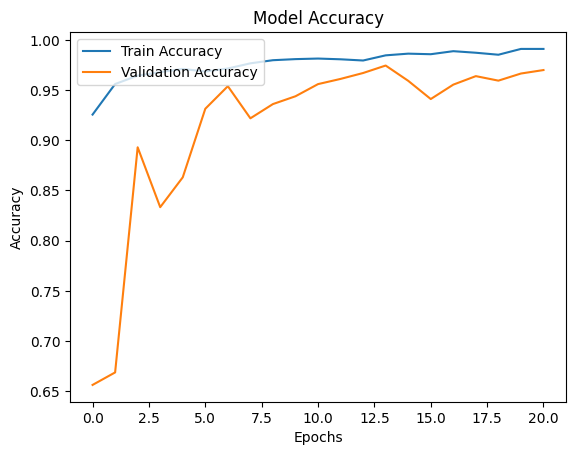

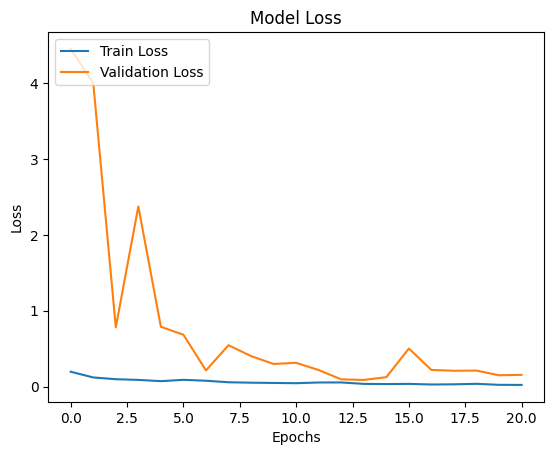

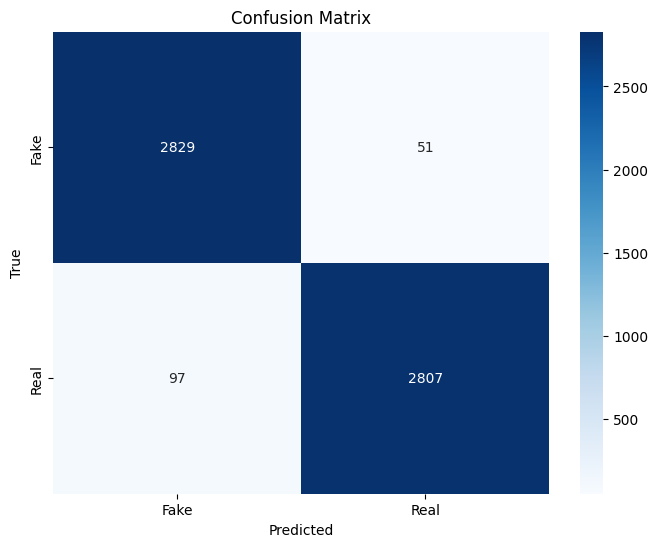

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 6. Plot training and validation loss/accuracy
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.show()



# 8. Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Classification Report:
               precision    recall  f1-score   support

        Fake       0.97      0.98      0.97      2880
        Real       0.98      0.97      0.97      2904

    accuracy                           0.97      5784
   macro avg       0.97      0.97      0.97      5784
weighted avg       0.97      0.97      0.97      5784



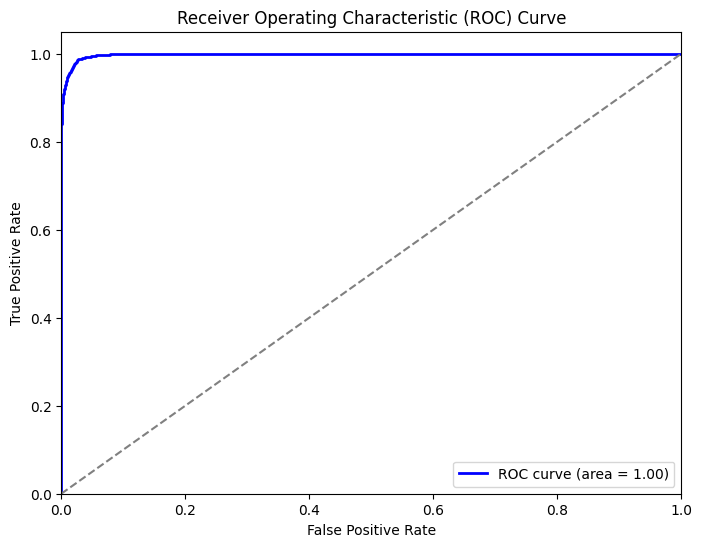

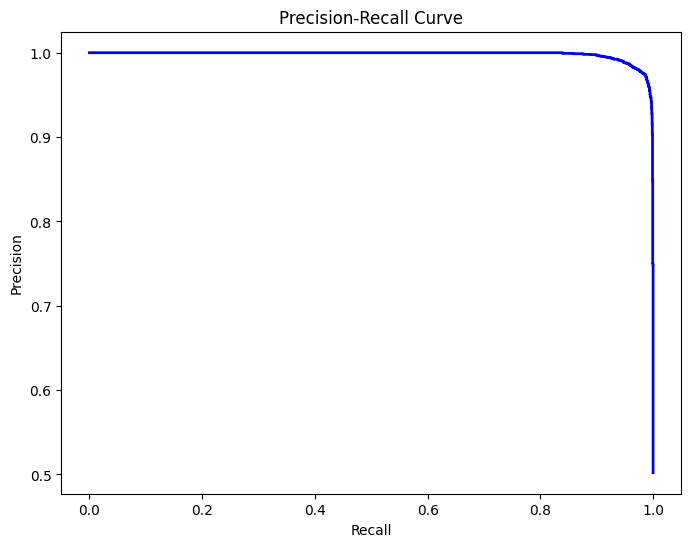

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# 1. Classification Report (Already printed in your code)
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))



# 3. ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_true_classes, y_pred[:, 1])  # Assuming binary classification for ROC curve
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true_classes, y_pred[:, 1])  # Assuming binary classification for PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()



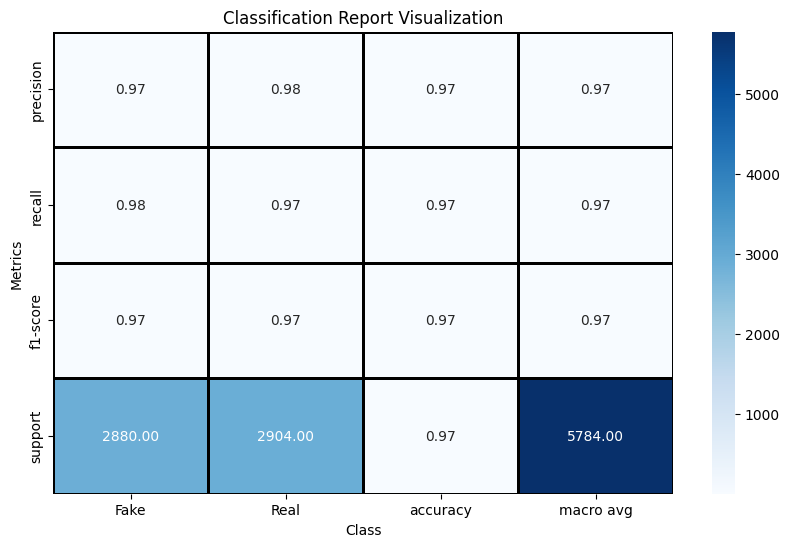

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Get the classification report as a dictionary
report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, output_dict=True)

# Convert the classification report to a pandas DataFrame
report_df = pd.DataFrame(report).transpose()

# Visualizing the classification report
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='Blues', fmt='.2f', linewidths=1, linecolor='black')
plt.title('Classification Report Visualization')
plt.xlabel('Class')
plt.ylabel('Metrics')
plt.show()
